In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

color_pal = sns.color_palette()

In [50]:
df = pd.read_excel('PGCB_date_power_demand.xlsx')
wea = pd.read_excel('weather_data.xlsx',skiprows=3)
eco = pd.read_csv('economic_full_1.csv')

# Data Cleaning and Integration

In [51]:
df['datetime'] = df['datetime'].dt.round('h')
df = df.drop_duplicates()
df.set_index('datetime', inplace=True)
df = df.sort_index()
df['india_adani']=df['india_adani'].fillna(0)
df['nepal'] = df['nepal'].fillna(0)
df['solar'] = df['solar'].fillna(0)
df['wind'] = df['wind'].fillna(0)

for col in df.columns:
  if col!='remarks':
    median = df[col].median()
    mad = np.median(np.abs(df[col] - median))

    if mad != 0:
        mod_z = 0.6745 * (df[col] - median) / mad
        df.loc[mod_z.abs() > 3, col] = np.nan
        df[col] = df[col].interpolate(method='linear', limit_direction='both')
        df[col] = df[col].ffill().bfill()

In [52]:
wea = wea.set_index('time')
wea = wea.sort_index()
wea = wea.drop_duplicates()

In [53]:
need = ['NY.GDP.MKTP.KD.ZG','SP.POP.TOTL','NV.IND.TOTL.ZS','FP.CPI.TOTL.ZG','EG.USE.PCAP.KG.OE','EG.EGY.PRIM.PP.KD']
eco = eco[eco['Indicator Code'].isin(need)]
eco = eco.set_index('Indicator Name')
eco =  eco.drop('Country Name',axis=1)
eco = eco.drop('Indicator Code',axis=1)
eco = eco.T
for col in eco.columns:
  if eco[col].isna().any():
    eco[col].interpolate(method='linear',limit_direction='both')
    eco[col] = eco[col].ffill().bfill()

In [54]:
wea.index.name = 'datetime'
df = df.join(wea, how='left')
df['Year'] = df.index.year
eco.index = eco.index.astype(int)
df = pd.merge(df, eco, left_on='Year', right_index=True, how='left')
df = df.drop(columns=['Year'])
df.index = pd.to_datetime(df.index)

In [55]:
import re

def clean_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = re.sub(r'[^a-zA-Z0-9_]', '_', col)
        new_col = re.sub(r'_{2,}', '_', new_col)
        new_col = new_col.strip('_')
        new_cols.append(new_col)
    df.columns = new_cols
    return df

df = clean_col_names(df)
print("Cleaned DataFrame Columns:")
print(df.columns)

Cleaned DataFrame Columns:
Index(['generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel',
       'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_tripura', 'india_adani', 'nepal', 'remarks', 'temperature_2m_C',
       'relative_humidity_2m', 'apparent_temperature_C', 'precipitation_mm',
       'dew_point_2m_C', 'soil_temperature_0_to_7cm_C', 'wind_direction_10m',
       'cloud_cover', 'sunshine_duration_s',
       'Inflation_consumer_prices_annual',
       'Energy_use_kg_of_oil_equivalent_per_capita', 'Population_total',
       'GDP_growth_annual',
       'Industry_including_construction_value_added_of_GDP',
       'Energy_intensity_level_of_primary_energy_MJ_2021_PPP_GDP'],
      dtype='object')


# Feature Engineering


In [56]:
df = df.drop(['remarks','temperature_2m_C','wind_direction_10m', 'cloud_cover','Industry_including_construction_value_added_of_GDP','soil_temperature_0_to_7cm_C','india_bheramara_hvdc',
       'india_tripura', 'india_adani', 'nepal', 'gas', 'liquid_fuel',
       'coal', 'hydro', 'solar', 'wind','Inflation_consumer_prices_annual',
       'Energy_use_kg_of_oil_equivalent_per_capita', 'Population_total',
       'GDP_growth_annual',
       'Energy_intensity_level_of_primary_energy_MJ_2021_PPP_GDP'],axis=1)
df['hour']=df.index.hour
df['dayofweek']=df.index.day_of_week
df['dayofweek_sin']=np.sin(2*np.pi*df['dayofweek']/7)
df['dayofweek_cos']=np.cos(2*np.pi*df['dayofweek']/7)
df['month']=df.index.month
df['month_sin']=np.sin(2*np.pi*df['month']/12)
df['month_cos']=np.cos(2*np.pi*df['month']/12)
df['weekend']=df['dayofweek'].isin([5,6]).astype(int)
df = df.drop(['dayofweek','month'],axis=1)
df['lag_1'] = df['demand_mw'].shift(1)
df['lag_24'] = df['demand_mw'].shift(24)
df['lag_168'] = df['demand_mw'].shift(168)
df['demand_trend'] = (df['demand_mw'].shift(1) - df['demand_mw'].shift(25)) / 24
df['demand_volatility_24h'] = df['demand_mw'].shift(1).rolling(24).std()
df['demand_momentum'] = df['demand_mw'].shift(1) - df['demand_mw'].shift(2)
df['ewma_4h'] = df['demand_mw'].shift(1).ewm(span=4, adjust=False).mean()
df['ewma_24h'] = df['demand_mw'].shift(1).ewm(span=24, adjust=False).mean()
df['roll_std_24'] = df['demand_mw'].shift(1).rolling(24).std()
df['target'] = df['demand_mw'].shift(-1)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['is_peak_hour'] = df['hour'].isin([10,11,12,18,19,20]).astype(int)
df['temp_high'] = (df['apparent_temperature_C'] > 30).astype(int)
df['temp_low'] = (df['apparent_temperature_C'] < 15).astype(int)
df['humid_temp'] = df['relative_humidity_2m'] * df['apparent_temperature_C'] / 100
df['temp_abs_deviation'] = np.abs(df['apparent_temperature_C'] - 25)  # Assume 25°C is "neutral"
df = df.drop('hour',axis=1)
df = df.drop('generation_mw',axis=1)
df = df.dropna()

# Training


In [57]:
split_date = '2024-01-01'

train_df = df[df.index < split_date]
val_df   = df[df.index >= split_date]

X_train = train_df.drop(columns=['target'])
y_train = train_df['target']

X_val = val_df.drop(columns=['target'])
y_val = val_df['target']

In [58]:
df.columns

Index(['demand_mw', 'load_shedding', 'relative_humidity_2m',
       'apparent_temperature_C', 'precipitation_mm', 'dew_point_2m_C',
       'sunshine_duration_s', 'dayofweek_sin', 'dayofweek_cos', 'month_sin',
       'month_cos', 'weekend', 'lag_1', 'lag_24', 'lag_168', 'demand_trend',
       'demand_volatility_24h', 'demand_momentum', 'ewma_4h', 'ewma_24h',
       'roll_std_24', 'target', 'hour_sin', 'hour_cos', 'is_peak_hour',
       'temp_high', 'temp_low', 'humid_temp', 'temp_abs_deviation'],
      dtype='object')

In [59]:
!pip install optuna

In [60]:
import optuna
from sklearn.metrics import mean_absolute_percentage_error
from lightgbm import LGBMRegressor # Now explicitly tuning LGBMRegressor

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "random_state": 42,
        "n_jobs": -1 # Use all available cores
    }

    model = LGBMRegressor(**params)

    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    return mean_absolute_percentage_error(y_val, preds)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=200)
print(f"best params: {study.best_params}")

[I 2026-04-19 08:19:30,435] A new study created in memory with name: no-name-e127fd28-9f16-4bbe-a748-097a8fd5a719


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020594 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4325
[LightGBM] [Info] Number of data points in the train set: 78988, number of used features: 28
[LightGBM] [Info] Start training from score 8369.756729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2026-04-19 08:19:33,625] Trial 0 finished with value: 0.02947527505313324 and parameters: {'n_estimators': 291, 'max_depth': 8, 'learning_rate': 0.24295658764239514, 'subsample': 0.5448576447269082, 'colsample_bytree': 0.9551310977412674}. Best is trial 0 with value: 0.02947527505313324.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.044368 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4325
[LightGBM] [Info] Number of data points in the train set: 78988, number of used features: 28
[LightGBM] [Info] Start training from score 8369.756729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

[I 2026-04-19 08:19:44,793] Trial 1 finished with value: 0.028721596880957836 and parameters: {'n_estimators': 426, 'max_depth': 3, 'learning_rate': 0.21412777385926798, 'subsample': 0.9441682811874594, 'colsample_bytree': 0.951194078737396}. Best is trial 1 with value: 0.028721596880957836.


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020966 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4325
[LightGBM] [Info] Number of data points in the train set: 78988, number of used features: 28
[LightGBM] [Info] Start training from score 8369.756729


[I 2026-04-19 08:44:37,239] Trial 198 finished with value: 0.0276606048529754 and parameters: {'n_estimators': 957, 'max_depth': 10, 'learning_rate': 0.02052889419965196, 'subsample': 0.8513134156355208, 'colsample_bytree': 0.961446538751517}. Best is trial 146 with value: 0.027375931848006484.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007510 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4325
[LightGBM] [Info] Number of data points in the train set: 78988, number of used features: 28
[LightGBM] [Info] Start training from score 8369.756729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2026-04-19 08:44:48,397] Trial 199 finished with value: 0.027906376577632803 and parameters: {'n_estimators': 1000, 'max_depth': 10, 'learning_rate': 0.013608000918343289, 'subsample': 0.8174070749139737, 'colsample_bytree': 0.969962445473179}. Best is trial 146 with value: 0.027375931848006484.


best params: {'n_estimators': 1000, 'max_depth': 10, 'learning_rate': 0.034591170828324636, 'subsample': 0.7757346599267606, 'colsample_bytree': 0.9572923128668338}


In [61]:
best_params = study.best_params

In [62]:
from lightgbm import LGBMRegressor as LGBMRe
from sklearn.metrics import mean_absolute_percentage_error
best_model = LGBMRe(**best_params)
best_model.fit(X_train, y_train)

feature_importances = best_model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

importance_df

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016690 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4325
[LightGBM] [Info] Number of data points in the train set: 78988, number of used features: 28
[LightGBM] [Info] Start training from score 8369.756729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,Feature,Importance
0,demand_mw,3119
21,hour_sin,2799
22,hour_cos,2120
17,demand_momentum,1992
15,demand_trend,1921
13,lag_24,1914
1,load_shedding,1534
14,lag_168,1453
16,demand_volatility_24h,1397
12,lag_1,1354


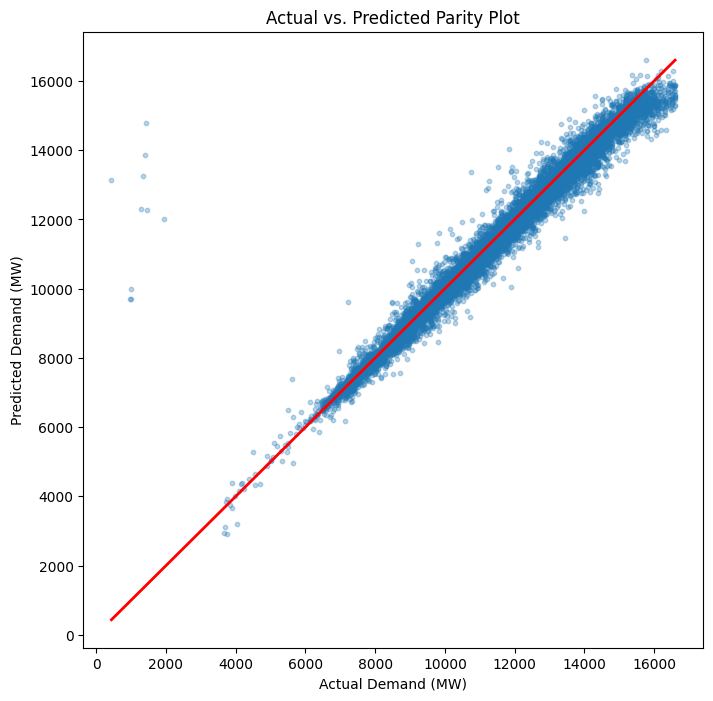

In [63]:
plt.figure(figsize=(8, 8))
y_test = y_val
y_pred = best_model.predict(X_val)
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Demand (MW)')
plt.ylabel('Predicted Demand (MW)')
plt.title('Actual vs. Predicted Parity Plot')
plt.savefig('parity_plot.png')

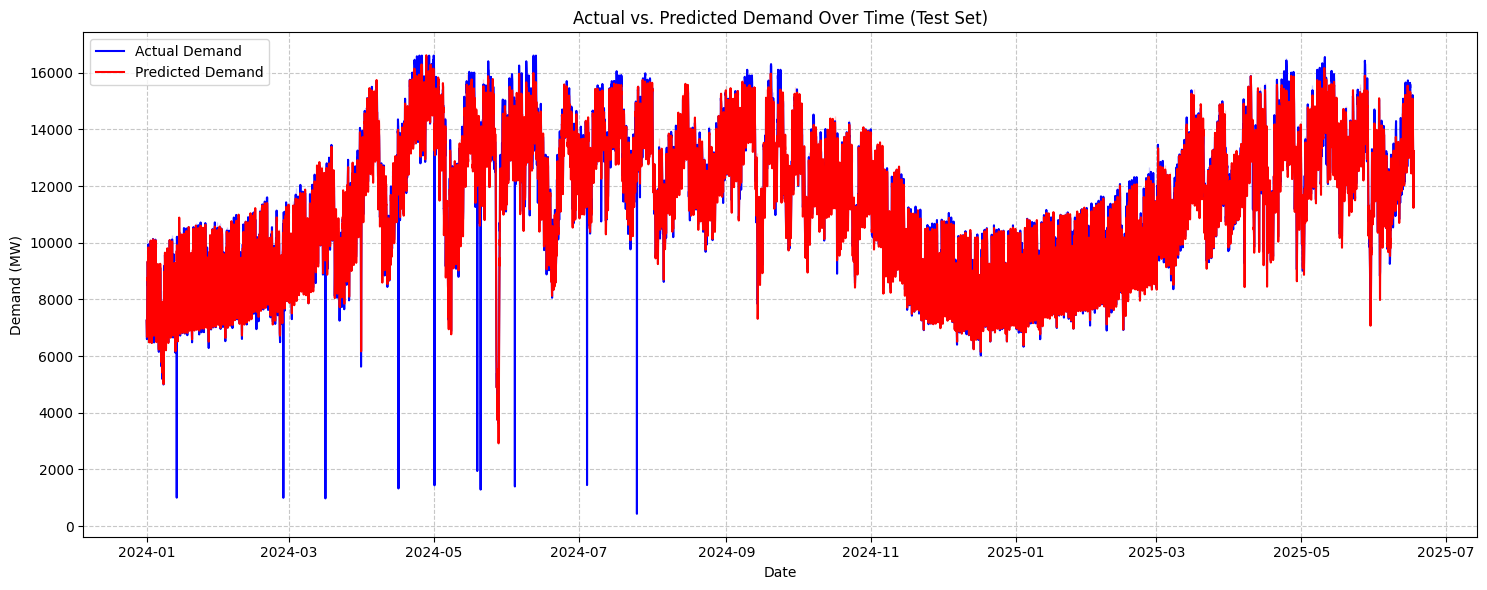

In [64]:
plt.figure(figsize=(15, 6))
sns.lineplot(x=y_test.index, y=y_test, label='Actual Demand', color='blue')
sns.lineplot(x=y_test.index, y=y_pred, label='Predicted Demand', color='red')
plt.title('Actual vs. Predicted Demand Over Time (Test Set)')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [65]:
mape_best_model = mean_absolute_percentage_error(y_val, y_pred)
print(f'MAPE for the best model: {mape_best_model:.2%}')

MAPE for the best model: 2.76%


In [66]:
from sklearn.metrics import mean_absolute_error
mae_best_model = mean_absolute_error(y_val, y_pred)
print(f'MAE for the best model: {mae_best_model:.2f} MW')

MAE for the best model: 237.10 MW
